Customer churn prediction  on Telco Customer Churn (IBM) dataset


In [ ]:
import pandas as pd
import numpy as nop
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_excel("/content/Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.shape

(7043, 33)

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
print(df.dtypes)
print(df.select_dtypes(include="number").columns)
print(pd.__version__)

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object
Index(['Count', 'Zip Code', '

In [ ]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [ ]:
# so here we have unwanted features so we will remove them
df.drop("CustomerID", axis=1, inplace=True)

In [ ]:
df.head(2)

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved


In [ ]:
df.drop("Churn Reason", axis=1, inplace=True)

In [ ]:
df.head(1)

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239


In [ ]:
# because lat long = latitude + longitude
df.drop("Lat Long", axis=1, inplace=True)

In [ ]:
df.head(1)

,Count,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,1,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239


In [ ]:
cat_cols=df.select_dtypes(include="object").columns
print(cat_cols)

Index(['Country', 'State', 'City', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Total Charges', 'Churn Label'],
      dtype='object')


In [ ]:
for cols in cat_cols:
  print(f"________{cols}________")
  print(pd.crosstab(df[cols], df["Churn Label"]))

________Country________
Churn Label      No   Yes
Country                  
United States  5174  1869
________State________
Churn Label    No   Yes
State                  
California   5174  1869
________City________
Churn Label   No  Yes
City                 
Acampo         1    3
Acton          4    0
Adelanto       4    1
Adin           2    2
Agoura Hills   3    2
...           ..  ...
Yreka          4    0
Yuba City      6    2
Yucaipa        3    1
Yucca Valley   5    0
Zenia          3    1

[1129 rows x 2 columns]
________Gender________
Churn Label    No  Yes
Gender                
Female       2549  939
Male         2625  930
________Senior Citizen________
Churn Label       No   Yes
Senior Citizen            
No              4508  1393
Yes              666   476
________Partner________
Churn Label    No   Yes
Partner                
No           2441  1200
Yes          2733   669
________Dependents________
Churn Label    No   Yes
Dependents             
No           3653  1763

In [ ]:
df.drop(["Country", "State"], axis=1 , inplace=True)

In [ ]:
df.head(3)

,Count,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,1,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,1,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,1,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372


In [ ]:
cat_cols=df.select_dtypes(include = "object").columns
for cols in cat_cols:
  print(f"{cols}")
  print(df[cols].nunique())

City
1129
Gender
2
Senior Citizen
2
Partner
2
Dependents
2
Phone Service
2
Multiple Lines
3
Internet Service
3
Online Security
3
Online Backup
3
Device Protection
3
Tech Support
3
Streaming TV
3
Streaming Movies
3
Contract
3
Paperless Billing
2
Payment Method
4
Total Charges
6531
Churn Label
2


In [ ]:
df.drop(["City"], axis=1, inplace=True)

In [ ]:

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].dtype

dtype('float64')

In [ ]:
nums_cols=df.select_dtypes(include="number").columns
print(nums_cols)

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')


In [ ]:
df.drop(["Churn Value", "Churn Score"], axis=1, inplace=True)

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,6500.000000


In [ ]:
nums_cols=df.select_dtypes(include="number").columns

Count


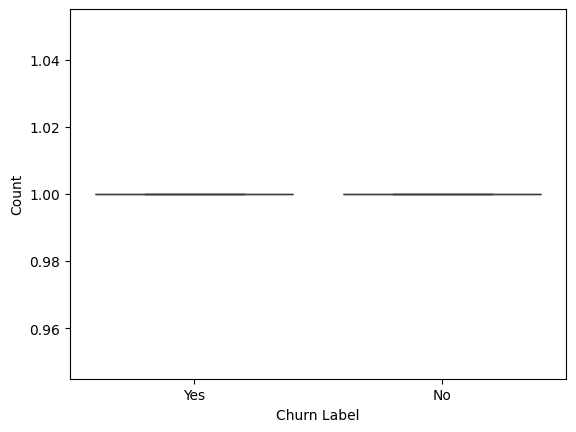

Zip Code


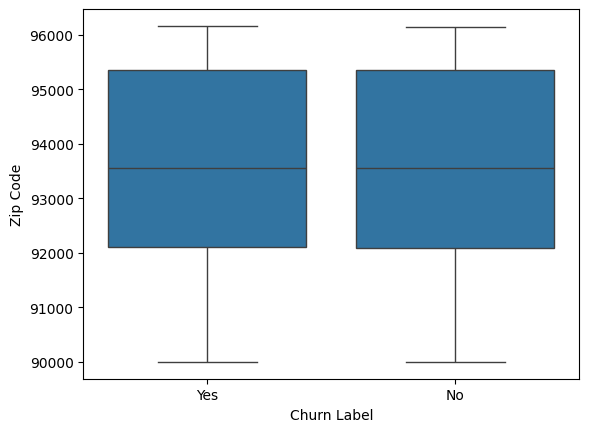

Latitude


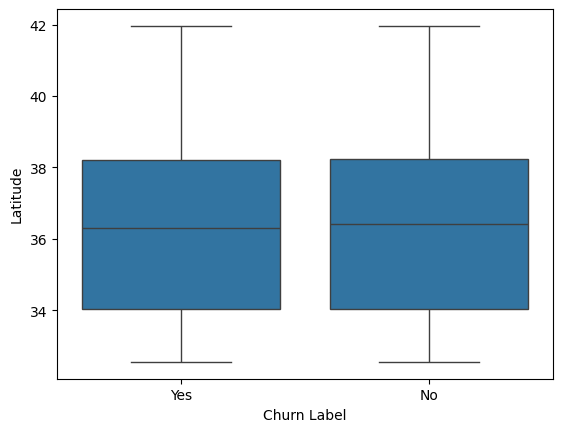

Longitude


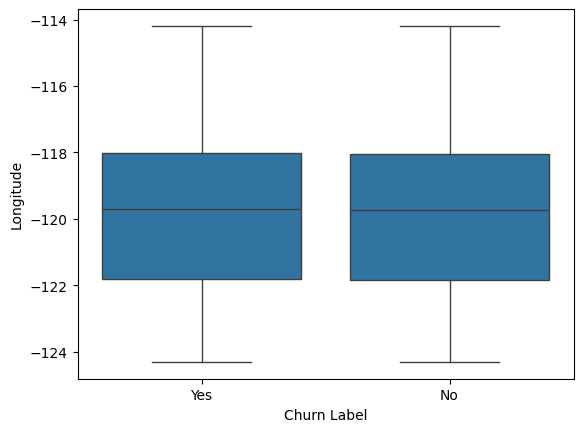

Tenure Months


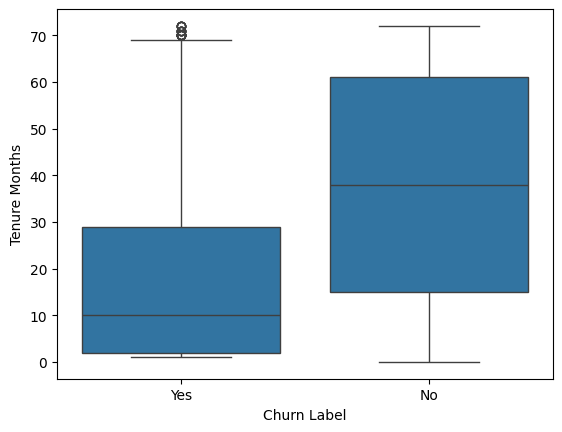

Monthly Charges


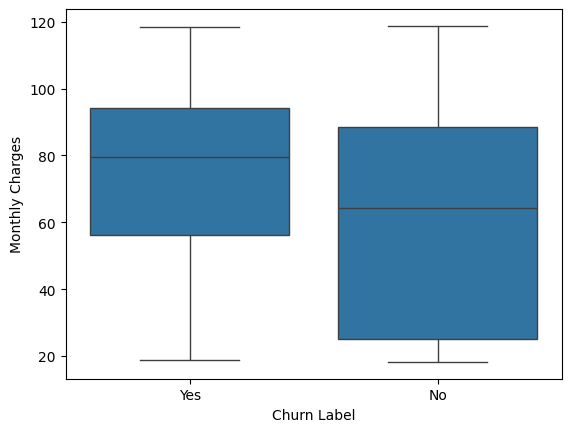

Total Charges


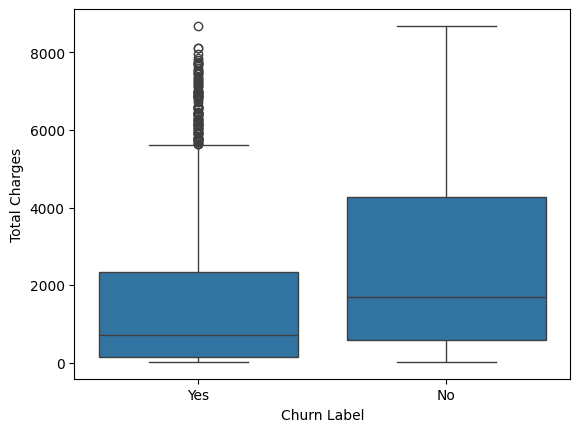

CLTV


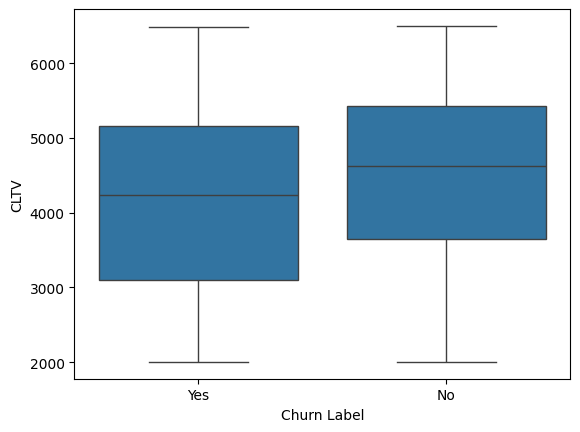

In [ ]:
for cols in nums_cols:
  print(f"{cols}")
  sns.boxplot(data=df, x="Churn Label", y=cols)
  plt.show()

In [ ]:
for col in nums_cols:
  print(f"{col}")
  print(df[col].nunique())

Count
1
Zip Code
1652
Latitude
1652
Longitude
1651
Tenure Months
73
Monthly Charges
1585
Total Charges
6530
CLTV
3438


In [ ]:
df.drop(["Count", "Zip Code", "Latitude", "Longitude"], axis=1, inplace=True)

In [ ]:
df.head(2)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701


In [ ]:
x=df.drop("Churn Label", axis=1)
y=df['Churn Label']

In [ ]:
cat_cols = x.select_dtypes(include="object").columns
num_cols = x.select_dtypes(include="number").columns

print(cat_cols)
print(num_cols)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')
Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV'], dtype='object')


In [ ]:
x= pd.get_dummies(x, drop_first=True)

In [ ]:
print(x.dtypes)

Tenure Months                               int64
Monthly Charges                           float64
Total Charges                             float64
CLTV                                        int64
Gender_Male                                  bool
Senior Citizen_Yes                           bool
Partner_Yes                                  bool
Dependents_Yes                               bool
Phone Service_Yes                            bool
Multiple Lines_No phone service              bool
Multiple Lines_Yes                           bool
Internet Service_Fiber optic                 bool
Internet Service_No                          bool
Online Security_No internet service          bool
Online Security_Yes                          bool
Online Backup_No internet service            bool
Online Backup_Yes                            bool
Device Protection_No internet service        bool
Device Protection_Yes                        bool
Tech Support_No internet service             bool


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
print(y)

[1 1 1 ... 0 0 0]


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

x_train["Total Charges"] = imputer.fit_transform(x_train[["Total Charges"]])


x_test["Total Charges"] = imputer.transform(x_test[["Total Charges"]])

In [ ]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
X_train_scaled = std.fit_transform(x_train)
X_test_scaled = std.transform(x_test)

In [ ]:
x_train.isnull().sum()

,0
Tenure Months,0
Monthly Charges,0
Total Charges,0
CLTV,0
Gender_Male,0
Senior Citizen_Yes,0
Partner_Yes,0
Dependents_Yes,0
Phone Service_Yes,0
Multiple Lines_No phone service,0


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
print(y_pred_lr)

[0 1 0 ... 0 0 0]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[915 120]
 [160 214]]


In [ ]:
import joblib as jb
jb.dump(lr,"LogisicticRegression.pkl")

['LogisicticRegression.pkl']

knn


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [ ]:
jb.dump(dt,"decisionTree.pkl")

['decisionTree.pkl']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)


In [ ]:


jb.dump(rf, "random_forest.pkl")

['random_forest.pkl']

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

In [ ]:
jb.dump(xgb, "xgboost.pkl")

['xgboost.pkl']

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, lr.predict(X_test_scaled))
accuracy_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
accuracy_dt = accuracy_score(y_test, dt.predict(x_test))
accuracy_rf = accuracy_score(y_test, rf.predict(x_test ))
accuracy_xgb = accuracy_score(y_test, xgb.predict(x_test))

print("Logistic Regression:", accuracy_lr)
print("KNN:", accuracy_knn)
print("Decision Tree:", accuracy_dt)
print("Random Forest:", accuracy_rf)
print("XGBoost:", accuracy_xgb)

Logistic Regression: 0.801277501774308
KNN: 0.7636621717530163
Decision Tree: 0.7324343506032647
Random Forest: 0.794889992902768
XGBoost: 0.7828246983676366


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf,
        accuracy_xgb
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.801278
1                  KNN  0.763662
2        Decision Tree  0.732434
3        Random Forest  0.794890
4              XGBoost  0.782825


In [ ]:
best_model_name = results.loc[results["Accuracy"].idxmax(), "Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [ ]:
import joblib

joblib.dump(lr, "best_model.pkl")
joblib.dump(std, "scaler.pkl")

['scaler.pkl']

In [ ]:
import os
print(os.listdir())

['.config', 'decisionTree.pkl', 'xgboost.pkl', 'Telco_customer_churn.xlsx', 'random_forest.pkl', 'scaler.pkl', 'LogisicticRegression.pkl', 'best_model.pkl', 'drive', 'sample_data']


In [ ]:
import joblib as jb
model_loaded = jb.load("best_model.pkl")